In [39]:
import mlflow

mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment("credit-card-fraud-detection")

<Experiment: artifact_location=('file:///c:/Users/psito/Dropbox/My PC '
 '(DESKTOP-AGH2G6E)/Downloads/Projects/creditcard-fraud-detection/notebooks/../mlruns/298219923567924079'), creation_time=1776036199825, experiment_id='298219923567924079', last_update_time=1776036199825, lifecycle_stage='active', name='credit-card-fraud-detection', tags={}>

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

df = pd.read_csv('../data/creditcard.csv')

legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

legit_train, legit_test = train_test_split(legit, test_size=0.2, random_state=5)
test_set = pd.concat([legit_test, fraud]).sample(frac=1, random_state=5)


scaler = StandardScaler()
legit_train = legit_train.copy()
test_set = test_set.copy()

legit_train[['Amount', 'Time']] = scaler.fit_transform(legit_train[['Amount', 'Time']])
test_set[['Amount', 'Time']] = scaler.transform(test_set[['Amount', 'Time']])

X_train = legit_train.drop('Class', axis=1).values
X_test = test_set.drop('Class', axis=1).values
y_test = test_set['Class'].values

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape} ")

Training set: (227452, 30)
Test set: (57355, 30) 


kNN works by measuring how isolated a transaction is from legitimate behavior. For each test transaction we find its k nearest neighbors in the legitimate training set and compute the average distance to those neighbors. A high average distance means the transaction looks nothing like any legitimate transaction, making it anomalous.


In [41]:
k_arr = [2, 5, 10, 20, 50]
k_auc_scores = {}

for k in k_arr:
  knn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
  knn.fit(X_train)
  distances, _ = knn.kneighbors(X_test)
  avg_distances = distances.mean(axis=1)

  precision, recall, thresholds = precision_recall_curve(y_test, avg_distances)
  f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

  best_idx = np.argmax(f1_scores)
  best_threshold = thresholds[best_idx]

  k_auc_scores[k] = {
      'precision': precision[:-1][best_idx],
      'recall': recall[:-1][best_idx],
      'best_f1_score': f1_scores[best_idx],
      'auc': auc(recall, precision),
      'best_threshold': best_threshold,
      'distances': avg_distances
  }
  print(f"k={k}: AUC={k_auc_scores[k]['auc']:.4f}, F1={k_auc_scores[k]['best_f1_score']:.4f}, Threshold={k_auc_scores[k]['best_threshold']:.4f}")


best_k = max(k_auc_scores, key=lambda k: k_auc_scores[k]['auc'])
best_threshold = k_auc_scores[best_k]['best_threshold']
best_precision = k_auc_scores[best_k]['precision']
best_recall = k_auc_scores[best_k]['recall']
best_f1_score = k_auc_scores[best_k]['best_f1_score']
print(f"Best k: {best_k} with AUC={k_auc_scores[best_k]['auc']:.4f} and F1={k_auc_scores[best_k]['best_f1_score']:.4f}")

k=2: AUC=0.6160, F1=0.6538, Threshold=6.0298
k=5: AUC=0.5891, F1=0.6515, Threshold=6.7898
k=10: AUC=0.5747, F1=0.6521, Threshold=7.2804
k=20: AUC=0.5853, F1=0.6667, Threshold=8.0227
k=50: AUC=0.6066, F1=0.6884, Threshold=8.7533
Best k: 2 with AUC=0.6160 and F1=0.6538


PR AUC was preferred over ROC AUC as the class is imbalanced. The ROC AUC score can be misleading as there may be a high amount of true negatives, whereas the PR AUC takes into consideration precision and recall in detecting fraud.

The optimal threshold will be the one maximizing F1 score. If the credit card is used fraudulently, missing the fraud event leads to total loss for the bank, whereas incorrectly identifying a transaction as fraudulent is merely an annoyance for the client and increased costs in handling the false alerts. As such, recall becomes more important than precision. F1-max provides a reasonable starting point when balancing recall and precision. Threshold would be lowered in production to increase recall despite the false positives.

[[56694   169]
 [  171   321]]

FPR: 0.0030


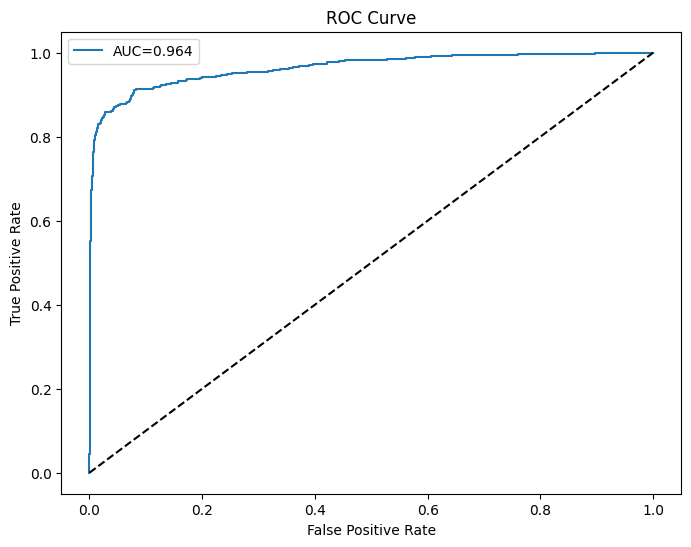

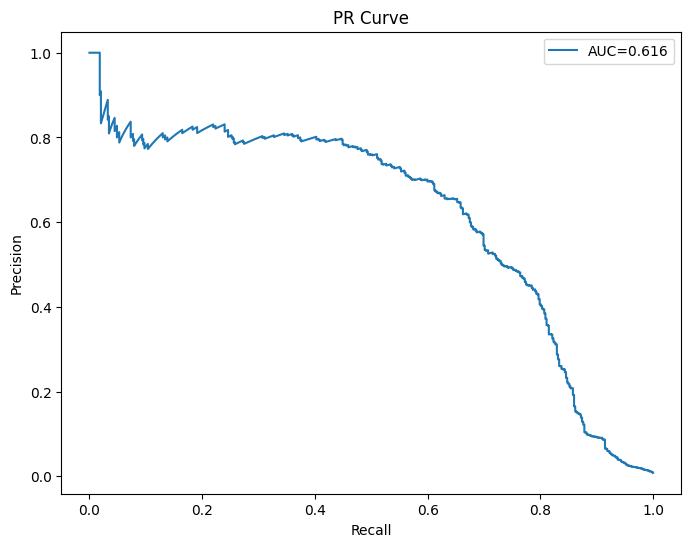

In [42]:
distances = k_auc_scores[best_k]['distances']

y_pred = (distances >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()

fpr_score = fp / (fp + tn)
print(f"\nFPR: {fpr_score:.4f}")

fpr, tpr, _ = roc_curve(y_test, distances)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

p, r, _ = precision_recall_curve(y_test, distances)
pr_auc = auc(r, p)
plt.figure(figsize=(8, 6))
plt.plot(r, p, label=f"AUC={pr_auc:.3f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve')
plt.legend()
plt.show()

The ROC curve shows a high AUC of 0.964, indicating that the model is very effective at ranking fraudulent transactions above legitimate ones. However, the PR curve presents a more realistic evaluation, with an AUC of 0.616, reflecting the challenge of maintaining high precision while increasing recall in a highly imbalanced dataset. This difference shows that ROC AUC can be overly optimistic in fraud detection tasks, whereas PR AUC provides a more informative measure of performance by focusing on the minority class.

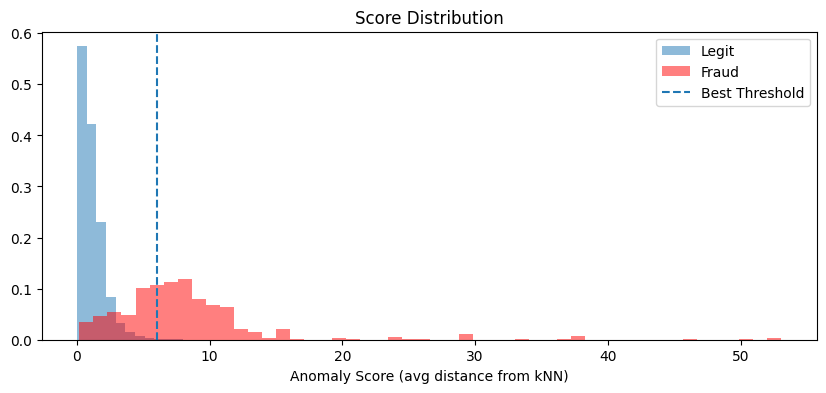

In [43]:
plt.figure(figsize=(10, 4))
plt.hist(distances[y_test==0], bins=50, alpha=0.5, label='Legit', density=True)
plt.hist(distances[y_test==1], bins=50, alpha=0.5, label='Fraud', color='red', density=True)
plt.axvline(best_threshold, linestyle='--', label='Best Threshold')
plt.xlabel('Anomaly Score (avg distance from kNN)')
plt.title('Score Distribution')
plt.legend()
plt.show()

There is clear separation in the score distribution regarding genuine and fraudulent cases. Genuine cases tend to have low scores and are tightly clustered, indicating that they are similar to the training data. On the other hand, fraudulent cases tend to scatter widely, particularly on the right-hand side, meaning that they are different from the norm. The separation line can classify most fraudulent cases as fraudulent, despite there being overlapping parts in both categories of scores. Such overlap shows the difficulty in fraud detection as there exist some similar-looking fraudulent cases.

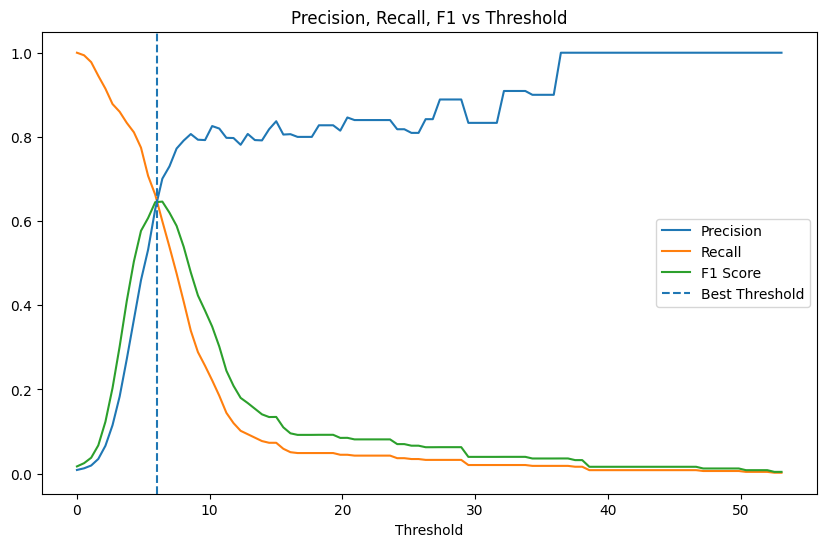

In [44]:
thresholds = np.linspace(distances.min(), distances.max(), 100)
results = []
for thresh in thresholds:
  y_pred = (distances >= thresh).astype(int)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  results.append((thresh, precision, recall, f1))
results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])

plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['F1'], label='F1 Score')
plt.axvline(best_threshold, linestyle='--', label='Best Threshold')
plt.xlabel('Threshold')
plt.title('Precision, Recall, F1 vs Threshold')
plt.legend()
plt.show()

The sensitivity analysis shows the expected tradeoff between precision and recall as the anomaly score threshold increases. Precision increases while recall decreases. The F1 score peaks around a threshold of approximately 6–7, indicating the optimal balance between precision and recall. The selected threshold aligns closely with this peak, confirming that it represents an effective operating point for fraud detection.

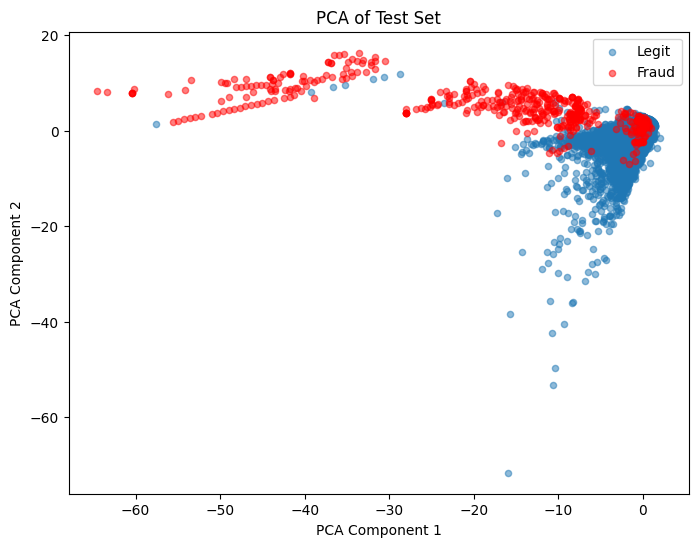

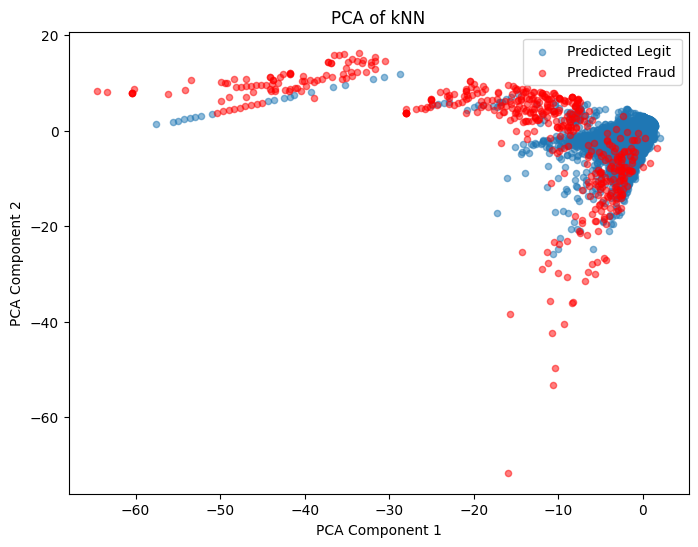

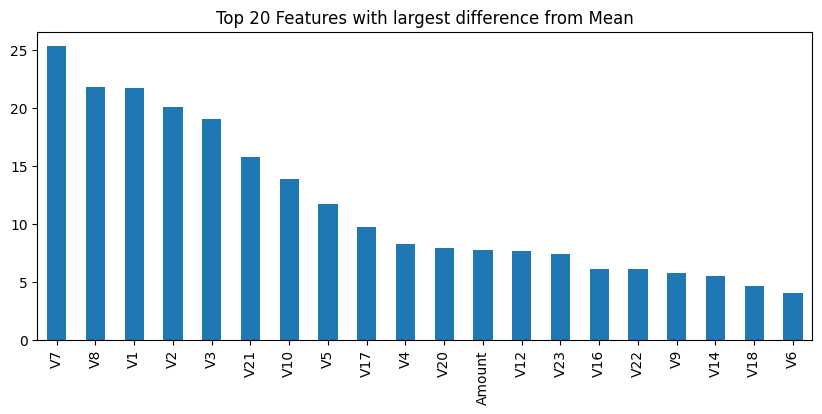

In [53]:
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[y_test==0][:,0], X_test_pca[y_test==0][:,1], alpha=0.5, label='Legit', s=20)
plt.scatter(X_test_pca[y_test==1][:,0], X_test_pca[y_test==1][:,1], alpha=0.5, label='Fraud', color='red', s=20)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Test Set')
plt.legend()
plt.show()

y_pred = (distances >= best_threshold).astype(int)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[y_pred==0][:,0], X_test_pca[y_pred==0][:,1], alpha=0.5, label='Predicted Legit', s=20)
plt.scatter(X_test_pca[y_pred==1][:,0], X_test_pca[y_pred==1][:,1], alpha=0.5, label='Predicted Fraud', color='red', s=20)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of kNN')
plt.legend()
plt.show()

top_idx = np.argsort(distances)[-20:]
feature = legit_train.drop('Class', axis=1).columns
top_df = pd.DataFrame(X_test[top_idx], columns=feature)
train_mean = X_train.mean(axis=0)

diff = (top_df - train_mean).abs().mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
diff.head(20).plot(kind='bar')
plt.title('Top 20 Features with largest difference from Mean')
plt.show()


The PCA plot shows that fraudulent transactions occupy regions of the feature space that are distinct from the dense cluster of legitimate transactions. The kNN model successfully identifies these regions, correctly classifying most fraud points that lie far from the normal cluster. However, some overlap exists between the two classes, leading to misclassifications in boundary regions. Analyzing features individually shows that anomalies deviate most strongly along specific components such as V7, V8, V1, V2 and V3, indicating that fraud is characterized by consistent patterns in certain feature directions rather than random noise.

In [46]:
for k in k_arr:
    with mlflow.start_run(run_name=f"knn_k_{k}"):
        mlflow.log_param("method", "knn")
        mlflow.log_param("k", k)
        mlflow.log_param("metric", "euclidean")
        mlflow.log_metric("pr_auc", k_auc_scores[k]['auc'])
        mlflow.log_metric("f1", k_auc_scores[k]['best_f1_score'])
        mlflow.log_metric("precision", k_auc_scores[k]['precision'])
        mlflow.log_metric("recall", k_auc_scores[k]['recall'])
        mlflow.log_metric("threshold", k_auc_scores[k]['best_threshold'])

np.save('../mlruns/knn.npy', distances)